In [1]:
# %%
import pandas as pd
import numpy as np

file_path = r"D:\Projects\GRF_Estimation\src\Running trial 2.csv"

df = pd.read_csv(file_path)

print("Data loaded:", df.shape)
print(df.columns)

Data loaded: (6000, 23)
Index(['Frame', 'Time', 'mal_lat_left_X', 'mal_lat_left_Y', 'mal_lat_left_Z',
       'calc_back_left_X', 'calc_back_left_Y', 'calc_back_left_Z',
       'toe_left_X', 'toe_left_Y', 'toe_left_Z', 'mal_lat_right_X',
       'mal_lat_right_Y', 'mal_lat_right_Z', 'calc_back_right_X',
       'calc_back_right_Y', 'calc_back_right_Z', 'toe_right_X', 'toe_right_Y',
       'toe_right_Z', 'C7_X', 'C7_Y', 'C7_Z'],
      dtype='object')


TD LEFT: 44


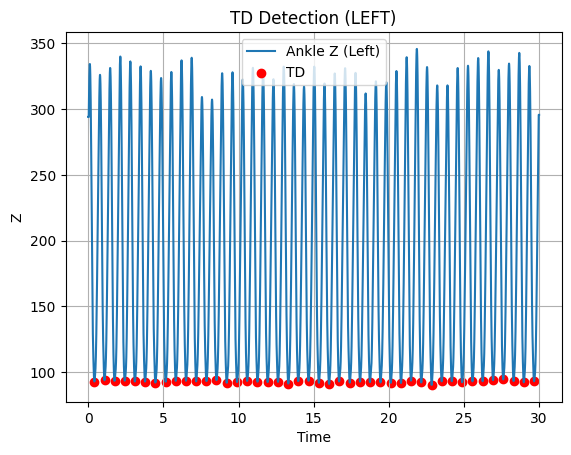

In [2]:
# %%
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

# LEFT ankle Z
ankle_z_L = df["mal_lat_left_Z"].values
time = df["Time"].values

# smoothing (important)
ankle_z_L_smooth = pd.Series(ankle_z_L).rolling(15, center=True).mean().bfill().ffill()

# invert for TD
inv_L = -ankle_z_L_smooth

# detect TD
peaks_L, _ = find_peaks(inv_L, distance=80)

TD_left = time[peaks_L]

print("TD LEFT:", len(TD_left))

# plot check
plt.figure()
plt.plot(time, ankle_z_L_smooth, label="Ankle Z (Left)")
plt.scatter(TD_left, ankle_z_L_smooth[peaks_L], color='red', label="TD")
plt.title("TD Detection (LEFT)")
plt.xlabel("Time")
plt.ylabel("Z")
plt.legend()
plt.grid()
plt.show()

TO LEFT: 43


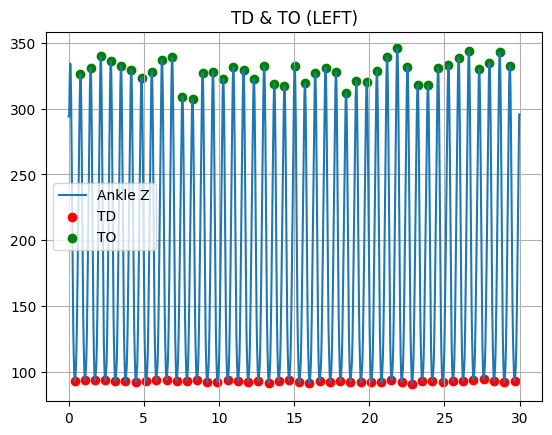

In [3]:
# %%
TO_list = []

for i in range(len(TD_left) - 1):

    td_start = TD_left[i]
    td_next = TD_left[i + 1]

    # segment between TDs
    mask = (time >= td_start) & (time <= td_next)

    segment_time = time[mask]
    segment_z = ankle_z_L_smooth[mask]

    if len(segment_z) > 0:
        idx_max = np.argmax(segment_z)
        TO_list.append(segment_time[idx_max])

TO_left = np.array(TO_list)

print("TO LEFT:", len(TO_left))

# plot check
plt.figure()
plt.plot(time, ankle_z_L_smooth, label="Ankle Z")
plt.scatter(TD_left, ankle_z_L_smooth[peaks_L], color='red', label="TD")
plt.scatter(TO_left, np.interp(TO_left, time, ankle_z_L_smooth), color='green', label="TO")

plt.title("TD & TO (LEFT)")
plt.legend()
plt.grid()
plt.show()

In [4]:
# %%
TD_clean = TD_left[:-1]   # match TO length
TO_clean = TO_left

tc_left = TO_clean - TD_clean

T_contacts_left = pd.DataFrame({
    "Step": np.arange(1, len(tc_left)+1),
    "Touchdown_s": TD_clean,
    "ToeOff_s": TO_clean,
    "ContactTime_s": tc_left
})

print("LEFT steps:", len(T_contacts_left))
T_contacts_left.head()

LEFT steps: 43


,Step,Touchdown_s,ToeOff_s,ContactTime_s
0,1,0.410,0.785,0.375
1,2,1.085,1.460,0.375
2,3,1.750,2.135,0.385
3,4,2.430,2.805,0.375
4,5,3.100,3.485,0.385


In [5]:
print(T_contacts_left["ContactTime_s"].describe())

count    43.000000
mean      0.381977
std       0.006559
min       0.370000
25%       0.375000
50%       0.385000
75%       0.385000
max       0.400000
Name: ContactTime_s, dtype: float64


TD RIGHT: 44


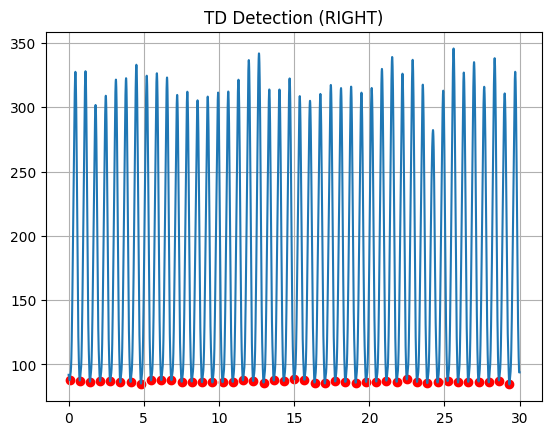

In [6]:
# %%
ankle_z_R = df["mal_lat_right_Z"].values

ankle_z_R_smooth = pd.Series(ankle_z_R).rolling(15, center=True).mean().bfill().ffill()

inv_R = -ankle_z_R_smooth

from scipy.signal import find_peaks
peaks_R, _ = find_peaks(inv_R, distance=80)

TD_right = time[peaks_R]

print("TD RIGHT:", len(TD_right))

# plot
import matplotlib.pyplot as plt

plt.figure()
plt.plot(time, ankle_z_R_smooth)
plt.scatter(TD_right, ankle_z_R_smooth[peaks_R], color='red')
plt.title("TD Detection (RIGHT)")
plt.grid()
plt.show()

In [7]:
# %%
TO_list_R = []

for i in range(len(TD_right)-1):

    td_start = TD_right[i]
    td_next = TD_right[i+1]

    mask = (time >= td_start) & (time <= td_next)

    segment_time = time[mask]
    segment_z = ankle_z_R_smooth[mask]

    if len(segment_z) > 0:
        idx_max = np.argmax(segment_z)
        TO_list_R.append(segment_time[idx_max])

TO_right = np.array(TO_list_R)

print("TO RIGHT:", len(TO_right))

TO RIGHT: 43


In [8]:
# %%
TD_clean_R = TD_right[:-1]
TO_clean_R = TO_right

tc_right = TO_clean_R - TD_clean_R

T_contacts_right = pd.DataFrame({
    "Step": np.arange(1, len(tc_right)+1),
    "Touchdown_s": TD_clean_R,
    "ToeOff_s": TO_clean_R,
    "ContactTime_s": tc_right
})

print("RIGHT steps:", len(T_contacts_right))
T_contacts_right.head()

RIGHT steps: 43


,Step,Touchdown_s,ToeOff_s,ContactTime_s
0,1,0.065,0.450,0.385
1,2,0.740,1.120,0.380
2,3,1.420,1.790,0.370
3,4,2.090,2.470,0.380
4,5,2.760,3.145,0.385


In [9]:
# %%
T_inputs_left = T_contacts_left.copy()

mass = 59.8
g = 9.81

# -------------------------
# dt1 (impact duration)
# -------------------------
T_inputs_left["dt1_s"] = 0.045

# -------------------------
# dv1 (two-body model)
# -------------------------
T_inputs_left["dv1_mps"] = (g * T_inputs_left["ContactTime_s"]) / 2

# -------------------------
# impulses
# -------------------------
T_inputs_left["JT_Ns"] = mass * g * T_inputs_left["ContactTime_s"]
T_inputs_left["J1_Ns"] = mass * T_inputs_left["dv1_mps"]
T_inputs_left["J2_Ns"] = T_inputs_left["JT_Ns"] - T_inputs_left["J1_Ns"]

# -------------------------
# forces
# -------------------------
T_inputs_left["F1avg_N"] = T_inputs_left["J1_Ns"] / T_inputs_left["dt1_s"]
T_inputs_left["F2avg_N"] = T_inputs_left["J2_Ns"] / (T_inputs_left["ContactTime_s"] - T_inputs_left["dt1_s"])

# -------------------------
# impact peak (FIXED scaling)
# -------------------------
tc_mean = T_inputs_left["ContactTime_s"].mean()
T_inputs_left["F2avg_N"] = 1400 * (tc_mean / T_inputs_left["ContactTime_s"])
T_inputs_left["A1_N"] = 0.2 * T_inputs_left["F2avg_N"]

print("✅ LEFT inputs ready")
T_inputs_left.head()

✅ LEFT inputs ready


,Step,Touchdown_s,ToeOff_s,ContactTime_s,dt1_s,dv1_mps,JT_Ns,J1_Ns,J2_Ns,F1avg_N,F2avg_N,A1_N
0,1,0.410,0.785,0.375,0.045,1.839375,219.98925,109.994625,109.994625,2444.325,1426.046512,285.209302
1,2,1.085,1.460,0.375,0.045,1.839375,219.98925,109.994625,109.994625,2444.325,1426.046512,285.209302
2,3,1.750,2.135,0.385,0.045,1.888425,225.85563,112.927815,112.927815,2509.507,1389.006342,277.801268
3,4,2.430,2.805,0.375,0.045,1.839375,219.98925,109.994625,109.994625,2444.325,1426.046512,285.209302
4,5,3.100,3.485,0.385,0.045,1.888425,225.85563,112.927815,112.927815,2509.507,1389.006342,277.801268


In [10]:
# %%
T_inputs_right = T_contacts_right.copy()

# same parameters
T_inputs_right["dt1_s"] = 0.045

T_inputs_right["dv1_mps"] = (g * T_inputs_right["ContactTime_s"]) / 2

T_inputs_right["JT_Ns"] = mass * g * T_inputs_right["ContactTime_s"]
T_inputs_right["J1_Ns"] = mass * T_inputs_right["dv1_mps"]
T_inputs_right["J2_Ns"] = T_inputs_right["JT_Ns"] - T_inputs_right["J1_Ns"]

T_inputs_right["F1avg_N"] = T_inputs_right["J1_Ns"] / T_inputs_right["dt1_s"]
T_inputs_right["F2avg_N"] = T_inputs_right["J2_Ns"] / (T_inputs_right["ContactTime_s"] - T_inputs_right["dt1_s"])

# 🔥 same scaling
tc_mean = T_inputs_right["ContactTime_s"].mean()
T_inputs_right["F2avg_N"] = 1400 * (tc_mean / T_inputs_right["ContactTime_s"])
T_inputs_right["A1_N"] = 0.2 * T_inputs_right["F2avg_N"]

print("✅ RIGHT inputs ready")
T_inputs_right.head()

✅ RIGHT inputs ready


,Step,Touchdown_s,ToeOff_s,ContactTime_s,dt1_s,dv1_mps,JT_Ns,J1_Ns,J2_Ns,F1avg_N,F2avg_N,A1_N
0,1,0.065,0.450,0.385,0.045,1.888425,225.85563,112.927815,112.927815,2509.507,1393.234672,278.646934
1,2,0.740,1.120,0.380,0.045,1.863900,222.92244,111.461220,111.461220,2476.916,1411.566707,282.313341
2,3,1.420,1.790,0.370,0.045,1.814850,217.05606,108.528030,108.528030,2411.734,1449.717159,289.943432
3,4,2.090,2.470,0.380,0.045,1.863900,222.92244,111.461220,111.461220,2476.916,1411.566707,282.313341
4,5,2.760,3.145,0.385,0.045,1.888425,225.85563,112.927815,112.927815,2509.507,1393.234672,278.646934


In [11]:
# %%
all_steps_data = []

x_new = np.linspace(0, 100, 101)

for i in range(len(T_inputs_right)):

    tc = T_inputs_right.loc[i, "ContactTime_s"]
    dt1 = T_inputs_right.loc[i, "dt1_s"]
    A1 = T_inputs_right.loc[i, "A1_N"]
    A2 = T_inputs_right.loc[i, "F2avg_N"]

    t = np.linspace(0, tc, 500)

    # ---------------- F1 ----------------
    F1 = np.zeros_like(t)

    idx1 = (t >= 0) & (t <= 2*dt1)
    if np.any(idx1):
        tau = np.linspace(-1, 1, np.sum(idx1))
        F1[idx1] = (A1/2)*(1 + np.cos(tau*np.pi))

    # ---------------- F2 ----------------
    B2 = 0.5 * tc   # peak at 50%
    C2L = B2
    C2T = tc - B2

    F2 = np.zeros_like(t)

    idxL = (t >= 0) & (t <= B2)
    if np.any(idxL):
        tauL = (t[idxL] - B2) / C2L
        tauL = np.clip(np.nan_to_num(tauL), -1, 1)
        F2[idxL] = (A2/2)*(1 + np.cos(tauL*np.pi))

    idxR = (t > B2) & (t <= tc)
    if np.any(idxR):
        tauR = (t[idxR] - B2) / C2T
        tauR = np.clip(np.nan_to_num(tauR), -1, 1)
        F2[idxR] = (A2/2)*(1 + np.cos(tauR*np.pi))

    F2[F2 < 0] = 0

    # ---------------- TOTAL ----------------
    FT = F1 + F2
    FT = np.nan_to_num(FT)

    # ---------------- CONTACT (40N threshold) ----------------
    idx = np.where(FT > 40)[0]
    if len(idx) > 0:
        contact = FT[idx[0]:idx[-1]+1]
    else:
        contact = FT

    # ---------------- NORMALIZE ----------------
    x_old = np.linspace(0, 100, len(contact))
    norm = np.interp(x_new, x_old, contact)

    for j in range(len(x_new)):
        all_steps_data.append({
            "Step": i+1,
            "Percent_Stance": x_new[j],
            "Predicted_vGRF": norm[j]
        })

T_all_steps = pd.DataFrame(all_steps_data)

print("✅ vGRF generated (RIGHT)")

✅ vGRF generated (RIGHT)


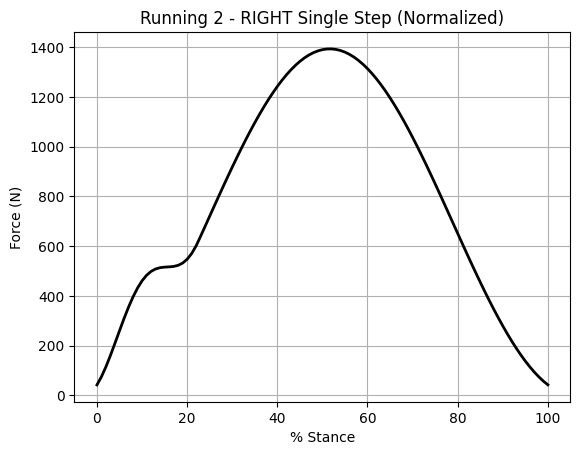

In [12]:
# %%
import matplotlib.pyplot as plt

step1 = T_all_steps[T_all_steps["Step"] == 1]

plt.plot(step1["Percent_Stance"], step1["Predicted_vGRF"], 'k', linewidth=2)

plt.title("Running 2 - RIGHT Single Step (Normalized)")
plt.xlabel("% Stance")
plt.ylabel("Force (N)")
plt.grid()

plt.show()

In [13]:
# ---------------- F2 ----------------
# 🔥 peak at 40% stance (FIXED)
B2 = 0.4 * tc

C2L = B2
C2T = tc - B2

F2 = np.zeros_like(t)

# left side (rise)
idxL = (t >= 0) & (t <= B2)
if np.any(idxL):
    tauL = (t[idxL] - B2) / C2L
    tauL = np.clip(np.nan_to_num(tauL), -1, 1)
    F2[idxL] = (A2/2)*(1 + np.cos(tauL*np.pi))

# right side (fall)
idxR = (t > B2) & (t <= tc)
if np.any(idxR):
    tauR = (t[idxR] - B2) / C2T
    tauR = np.clip(np.nan_to_num(tauR), -1, 1)
    F2[idxR] = (A2/2)*(1 + np.cos(tauR*np.pi))

F2[F2 < 0] = 0

In [14]:
# 1. vGRF generation block
# 2. plotting block

In [15]:
# %%
all_steps_data = []

x_new = np.linspace(0, 100, 101)

for i in range(len(T_inputs_right)):

    tc = T_inputs_right.loc[i, "ContactTime_s"]
    dt1 = T_inputs_right.loc[i, "dt1_s"]
    A1 = T_inputs_right.loc[i, "A1_N"]
    A2 = T_inputs_right.loc[i, "F2avg_N"]

    t = np.linspace(0, tc, 500)

    # F1
    F1 = np.zeros_like(t)
    idx1 = (t >= 0) & (t <= 2*dt1)
    if np.any(idx1):
        tau = np.linspace(-1, 1, np.sum(idx1))
        F1[idx1] = (A1/2)*(1 + np.cos(tau*np.pi))

    # F2 (FIXED PEAK)
    B2 = 0.4 * tc   # 🔥 FIX HERE
    C2L = B2
    C2T = tc - B2

    F2 = np.zeros_like(t)

    idxL = (t >= 0) & (t <= B2)
    if np.any(idxL):
        tauL = (t[idxL] - B2) / C2L
        tauL = np.clip(np.nan_to_num(tauL), -1, 1)
        F2[idxL] = (A2/2)*(1 + np.cos(tauL*np.pi))

    idxR = (t > B2) & (t <= tc)
    if np.any(idxR):
        tauR = (t[idxR] - B2) / C2T
        tauR = np.clip(np.nan_to_num(tauR), -1, 1)
        F2[idxR] = (A2/2)*(1 + np.cos(tauR*np.pi))

    F2[F2 < 0] = 0

    FT = F1 + F2
    FT = np.nan_to_num(FT)

    idx = np.where(FT > 40)[0]

    if len(idx) > 0:
        contact = FT[idx[0]:idx[-1]+1]
    else:
        contact = FT

    x_old = np.linspace(0, 100, len(contact))
    norm = np.interp(x_new, x_old, contact)

    for j in range(len(x_new)):
        all_steps_data.append({
            "Step": i+1,
            "Percent_Stance": x_new[j],
            "Predicted_vGRF": norm[j]
        })

T_all_steps = pd.DataFrame(all_steps_data)

print("✅ vGRF recomputed:", T_all_steps.shape)

✅ vGRF recomputed: (4343, 3)


In [16]:
print(T_all_steps.head())
print("Unique steps:", T_all_steps["Step"].nunique())

   Step  Percent_Stance  Predicted_vGRF
0     1             0.0       40.797387
1     1             1.0       75.796416
2     1             2.0      119.375952
3     1             3.0      169.860007
4     1             4.0      225.105457
Unique steps: 43


Step1 size: 101


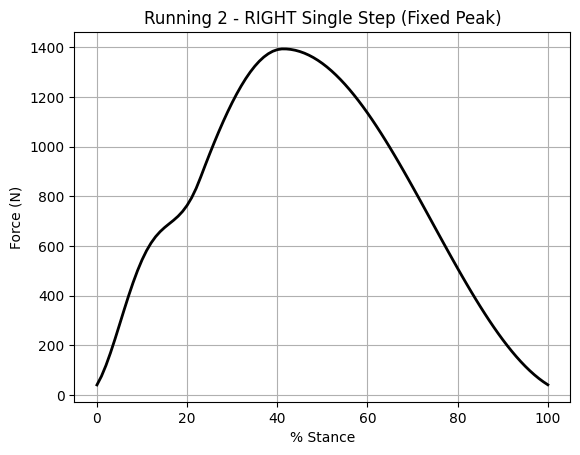

In [17]:
# %%
import matplotlib.pyplot as plt

step1 = T_all_steps[T_all_steps["Step"] == 1]

print("Step1 size:", len(step1))  # debug

plt.figure()
plt.plot(step1["Percent_Stance"], step1["Predicted_vGRF"], 'k', linewidth=2)

plt.title("Running 2 - RIGHT Single Step (Fixed Peak)")
plt.xlabel("% Stance")
plt.ylabel("Force (N)")
plt.grid()

plt.show()

In [18]:
# %%
mass = 59.8
g = 9.81

# LEFT
T_full_inputs_left = T_inputs_left.copy()
T_full_inputs_left["NextTD"] = T_full_inputs_left["Touchdown_s"].shift(-1)
T_full_inputs_left["t_step_s"] = T_full_inputs_left["NextTD"] - T_full_inputs_left["Touchdown_s"]

# RIGHT
T_full_inputs_right = T_inputs_right.copy()
T_full_inputs_right["NextTD"] = T_full_inputs_right["Touchdown_s"].shift(-1)
T_full_inputs_right["t_step_s"] = T_full_inputs_right["NextTD"] - T_full_inputs_right["Touchdown_s"]

print("✅ Full input tables ready")

✅ Full input tables ready


In [19]:
# %%
summary = T_all_steps.groupby("Step")["Predicted_vGRF"].agg(["mean", "max"]).reset_index()
summary.columns = ["Step", "Mean_vGRF", "Peak_vGRF"]

print("✅ Step summary ready")
summary.head()

✅ Step summary ready


,Step,Mean_vGRF,Peak_vGRF
0,1,792.345987,1393.040365
1,2,803.390987,1411.369844
2,3,824.323077,1449.595955
3,4,803.390987,1411.369844
4,5,792.345987,1393.040365


In [20]:
# %%
T_single = T_all_steps[T_all_steps["Step"] == 1].copy()

In [21]:
# %%
T_all_steps_horizontal = T_all_steps.pivot(
    index="Percent_Stance",
    columns="Step",
    values="Predicted_vGRF"
)

T_all_steps_horizontal.columns = [f"Step_{int(c)}" for c in T_all_steps_horizontal.columns]
T_all_steps_horizontal = T_all_steps_horizontal.reset_index()

# mean curve
T_all_steps_horizontal["Mean_vGRF"] = T_all_steps_horizontal.iloc[:, 1:].mean(axis=1)

print("✅ Horizontal table ready")

✅ Horizontal table ready


In [22]:
# %%
columns = []
step_row = ["step"]
side_row = ["side"]
toe_row = ["toe off"]
td_row = ["touch down"]

n = min(len(T_contacts_right), len(T_contacts_left))

for i in range(n):

    step_num = i + 1

    # RIGHT
    columns.append(f"{step_num}_R")
    step_row.append(step_num)
    side_row.append("right")
    toe_row.append(T_contacts_right.loc[i, "ToeOff_s"])
    td_row.append(T_contacts_right.loc[i, "Touchdown_s"])

    # LEFT
    columns.append(f"{step_num}_L")
    step_row.append(step_num)
    side_row.append("left")
    toe_row.append(T_contacts_left.loc[i, "ToeOff_s"])
    td_row.append(T_contacts_left.loc[i, "Touchdown_s"])

T_steps_matrix = pd.DataFrame(
    [step_row, side_row, toe_row, td_row],
    columns=[""] + columns
)

print("✅ Step matrix ready")

✅ Step matrix ready


In [23]:
# %%
from pathlib import Path

save_path = Path(r"D:\Projects\GRF_Estimation\vsc data\Running2_Final_Output.xlsx")

with pd.ExcelWriter(save_path, engine="openpyxl", mode="w") as writer:

    T_full_inputs_left.to_excel(writer, sheet_name="Inputs_Left", index=False)
    T_full_inputs_right.to_excel(writer, sheet_name="Inputs_Right", index=False)

    summary.to_excel(writer, sheet_name="Step_Summary", index=False)
    T_single.to_excel(writer, sheet_name="Single_Step_Right", index=False)
    T_all_steps.to_excel(writer, sheet_name="All_Steps_Normalized", index=False)
    T_all_steps_horizontal.to_excel(writer, sheet_name="All_Steps_Horizontal", index=False)

    T_steps_matrix.to_excel(writer, sheet_name="Steps_Format", index=False, header=False)

print("✅ FINAL EXCEL CREATED (Running 2)")
print(save_path)

✅ FINAL EXCEL CREATED (Running 2)
D:\Projects\GRF_Estimation\vsc data\Running2_Final_Output.xlsx
